<a href="https://colab.research.google.com/github/AseelAlnoor/Cyclistic-Bike-Share-Analysis/blob/main/cyclistic_bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> ## **Project: Cyclistic Bike-Share Analysis**
>
> ### **1. Introduction**
> This project is part of the **Google Data Analytics Professional Certificate**. The goal is to analyze historical bike trip data to identify trends in how different user types (Annual Members vs. Casual Riders) use the service.
>
> ### **2. Business Task**
> Design marketing strategies aimed at converting casual riders into annual members by understanding their behavior.
>
> ### **3. Technical Workflow**
> In this notebook, I perform the following steps:
> * **Data Ingestion:** Unzipping and merging 12 months of CSV data.
> * **Processing:** Cleaning missing values and removing erroneous data (e.g., negative trip durations).
> * **Feature Engineering:** Creating new columns for trip length, day of the week, and month.
> * **Analysis:** Grouping data to find patterns and averages.



##step 1: enviroment setup and data ingestion

In [ ]:
#connect to google drive to access the dataset folder
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import essential libraries for data processing and file handling
import pandas as pd
import zipfile
import os

In [ ]:
# 1. define folder path
zip_folder = '/content/drive/MyDrive/cyclistic_zips'
extract_to = '/content/drive/MyDrive/Cyclistic_Raw_Data'

# 2. check if the destination folder exists
if not os.path.exists(extract_to):
    os.makedirs(extract_to)
    print("new folder created successfully.")

# 3. loop through the zip folder and extract every zip file
for filename in os.listdir(zip_folder):
    if filename.endswith('.zip'):
        file_path = os.path.join(zip_folder, filename)
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
            print(f"Extracted: {filename}")

Extracted: 202004-divvy-tripdata.zip
Extracted: 202005-divvy-tripdata.zip
Extracted: 202006-divvy-tripdata.zip
Extracted: 202008-divvy-tripdata.zip
Extracted: 202007-divvy-tripdata.zip
Extracted: 202012-divvy-tripdata.zip
Extracted: 202102-divvy-tripdata.zip
Extracted: 202103-divvy-tripdata.zip
Extracted: 202011-divvy-tripdata.zip
Extracted: 202101-divvy-tripdata.zip
Extracted: 202010-divvy-tripdata.zip
Extracted: 202009-divvy-tripdata.zip


In [ ]:
import glob

# 1. define the path where the unzipped csv files are loceted
path = '/content/drive/MyDrive/Cyclistic_Raw_Data'

# 2. list all csv files in the folder
all_files = glob.glob(os.path.join(path, "*.csv"))

# 3. read each csv file and store it in a list of DataFrame
li = []
for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)

# 4. concatenate all DataFrame
df_all = pd.concat(li, axis=0, ignore_index=True)


print("files merged successfully")
print(f"total row count: {len(df_all)}")

files merged successfully
total row count: 3489748


In [ ]:
#preview the firet 5 rows
df_all.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,A847FADBBC638E45,docked_bike,2020-04-26 17:45:14,2020-04-26 18:12:03,Eckhart Park,86,Lincoln Ave & Diversey Pkwy,152.0,41.8964,-87.6610,41.9322,-87.6586,member
1,5405B80E996FF60D,docked_bike,2020-04-17 17:08:54,2020-04-17 17:17:03,Drake Ave & Fullerton Ave,503,Kosciuszko Park,499.0,41.9244,-87.7154,41.9306,-87.7238,member
2,5DD24A79A4E006F4,docked_bike,2020-04-01 17:54:13,2020-04-01 18:08:36,McClurg Ct & Erie St,142,Indiana Ave & Roosevelt Rd,255.0,41.8945,-87.6179,41.8679,-87.6230,member
3,2A59BBDF5CDBA725,docked_bike,2020-04-07 12:50:19,2020-04-07 13:02:31,California Ave & Division St,216,Wood St & Augusta Blvd,657.0,41.9030,-87.6975,41.8992,-87.6722,member
4,27AD306C119C6158,docked_bike,2020-04-18 10:22:59,2020-04-18 11:15:54,Rush St & Hubbard St,125,Sheridan Rd & Lawrence Ave,323.0,41.8902,-87.6262,41.9695,-87.6547,casual


In [ ]:
#inspecting the structure and summary of the merged DataFrame
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489748 entries, 0 to 3489747
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 346.1+ MB


##step 2: Data Cleaning & Transformation


In [ ]:
# convert ride timestamp columns from string to datetime object
df_all['started_at'] = pd.to_datetime(df_all['started_at'])
df_all['ended_at'] = pd.to_datetime(df_all['ended_at'])

# verify the conversion
print("updated column data types:")
print(df_all[['started_at', 'ended_at']].dtypes)

updated column data types:
started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489748 entries, 0 to 3489747
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(4), object(7)
memory usage: 346.1+ MB


##Step 3: Data Analysis & visualization

In [ ]:
# 1. Calculate ride duration in minutes (if not calculated before)
df_all['ride_length_mins'] = (df_all['ended_at'] - df_all['started_at']).dt.total_seconds() / 60

# 2. Extract day of the week
df_all['day_of_week'] = df_all['started_at'].dt.day_name()

# 3. Actual cleaning: remove rides with duration zero or less (erroneous data)
df_clean = df_all[df_all['ride_length_mins'] > 0]

# 4. Remove rows with missing values (NaN) in important columns
# (to ensure that any trip we analyze has a start and end location)
df_clean = df_clean.dropna(subset=['start_station_name', 'end_station_name'])

print("Cleaning successful!")
print(f"Number of rows after cleaning: {len(df_clean)}")

Cleaning successful!
Number of rows after cleaning: 3284820


In [ ]:
# 1. check for missing values in each column
print("missing values per column:")
print(df_all.isnull().sum())

# 2. identify invalid rides
invalid_rides = df_all[df_all['ride_length_mins'] <= 0].shape[0]
print(f"\nNumber of invalid rides: {invalid_rides}")

missing values per column:
ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    122175
start_station_id      122801
end_station_name      143242
end_station_id        143703
start_lat                  0
start_lng                  0
end_lat                 4738
end_lng                 4738
member_casual              0
ride_length_mins           0
day_of_week                0
dtype: int64

Number of invalid rides: 10938


In [ ]:
# 1. Compare average ride duration between the two categories
comparison = df_clean.groupby('member_casual')['ride_length_mins'].mean()

print("Average ride duration (in minutes):")
print(comparison)

# 2. Determine who rides more on each day of the week
weekly_trips = df_clean.groupby(['member_casual', 'day_of_week']).size()

print("\nNumber of trips by day of the week:")
print(weekly_trips)

Average ride duration (in minutes):
member_casual
casual    45.446829
member    15.934110
Name: ride_length_mins, dtype: float64

Number of trips by day of the week:
member_casual  day_of_week
casual         Friday         196520
               Monday         142058
               Saturday       319105
               Sunday         249819
               Thursday       156236
               Tuesday        136249
               Wednesday      148389
member         Friday         288930
               Monday         251916
               Saturday       304652
               Sunday         250523
               Thursday       283761
               Tuesday        268241
               Wednesday      288421
dtype: int64


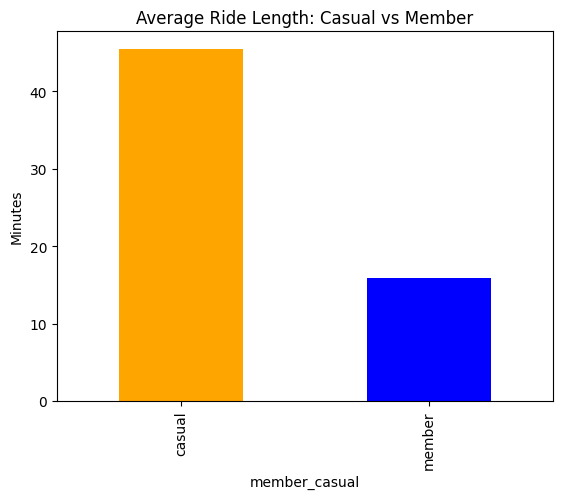

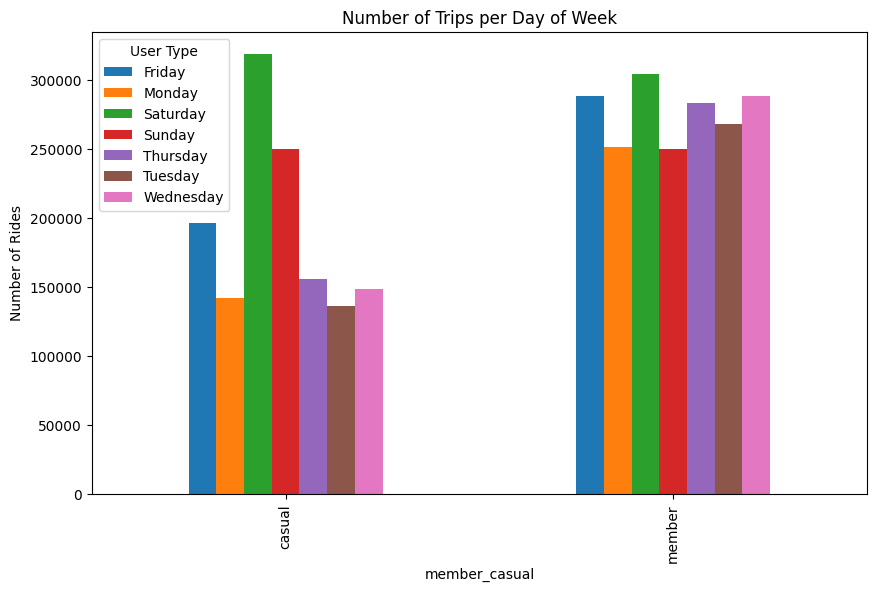

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot to compare average ride duration
comparison.plot(kind='bar', color=['orange', 'blue'])
plt.title('Average Ride Length: Casual vs Member')
plt.ylabel('Minutes')
plt.show()

# 2. Plot number of trips by day of the week
weekly_trips.unstack().plot(kind='bar', figsize=(10,6))
plt.title('Number of Trips per Day of Week')
plt.ylabel('Number of Rides')
plt.legend(title='User Type')
plt.show()

In [ ]:
# 1. Save the cleaned table to a new CSV file in Drive
df_clean.to_csv('/content/drive/MyDrive/Cyclistic_Final_Clean_Data.csv', index=False)

# 2. Save the comparison summary to a small file
comparison.to_csv('/content/drive/MyDrive/Cyclistic_Summary_Results.csv')

print("Congratulations, seven! All files have been successfully saved to Google Drive.")

Congratulations, seven! All files have been successfully saved to Google Drive.


In [ ]:
df_sample = df_clean.sample(n=100000, random_state=42)

print("Sampled DataFrame head:")
display(df_sample.head())

print(f"\nShape of the sampled DataFrame: {df_sample.shape}")

Sampled DataFrame head:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length_mins,day_of_week
1474913,AF5FD01E08ECF0FF,docked_bike,2020-07-11 09:56:47,2020-07-11 10:14:08,Montrose Harbor,249.0,Broadway & Granville Ave,454.0,41.963982,-87.638181,41.994780,-87.660285,member,17.350000,Saturday
2329387,92276B8E68FD78DC,docked_bike,2020-11-10 08:31:21,2020-11-10 08:46:26,Broadway & Berwyn Ave,294.0,Broadway & Argyle St,295.0,41.978353,-87.659753,41.973815,-87.659660,member,15.083333,Tuesday
3110639,04546584DF23D218,electric_bike,2020-09-16 19:01:00,2020-09-16 21:06:16,Rhodes Ave & 32nd St,263.0,Wabash Ave & 9th St,321.0,41.836739,-87.613396,41.870610,-87.625881,casual,125.266667,Wednesday
1677500,151C92BF52357D55,docked_bike,2020-07-06 12:15:33,2020-07-06 12:19:50,Broadway & Waveland Ave,304.0,Sheridan Rd & Buena Ave,306.0,41.949074,-87.648636,41.958494,-87.654966,member,4.283333,Monday
1640484,0B321C70FEA7442A,docked_bike,2020-07-08 19:27:22,2020-07-08 19:48:54,Desplaines St & Randolph St,96.0,Lake Shore Dr & North Blvd,268.0,41.884616,-87.644570,41.911722,-87.626804,casual,21.533333,Wednesday



Shape of the sampled DataFrame: (100000, 15)


In [ ]:
df_sample.to_csv('/content/drive/MyDrive/Cyclistic_Sampled_Data.csv', index=False)
print("Sample file saved successfully to Google Drive.")

Sample file saved successfully to Google Drive.
